In [0]:
# ============================================================
# Notebook 3: Exploratory Data Analysis (EDA)
# ATP Tennis Dataset (2000-2026)
# ============================================================

storage_account = "tennisdatalake60105845"
storage_key =  "LjZoIlf5yGSIHxM/9GIXHx5jTq8VNvMOqWjuLZ54krBy3gn+BN7pg8q5/4UM8dgtAEwIMaTNyIYl+AStqzCGpQ=="

spark.conf.set(
    f"fs.azure.account.key.{storage_account}.dfs.core.windows.net",
    storage_key
)

# Load cleaned data
df = spark.read.format("delta").table("amazon_dbx_60105845.default.atp_tennis_clean")

print(f" Loaded {df.count()} records")

# Convert to pandas for visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_pd = df.toPandas()
print(df_pd.describe())

 Loaded 67460 records
            Best_of        Rank_1  ...          year         month
count  67460.000000  67446.000000  ...  67460.000000  67460.000000
mean       3.376727     75.805533  ...   2012.213786      5.569864
std        0.782010    100.493488  ...      7.671453      2.990301
min        3.000000      1.000000  ...   2000.000000      1.000000
25%        3.000000     24.000000  ...   2006.000000      3.000000
50%        3.000000     53.000000  ...   2012.000000      6.000000
75%        3.000000     92.000000  ...   2019.000000      8.000000
max        5.000000   3390.000000  ...   2026.000000     12.000000

[8 rows x 10 columns]


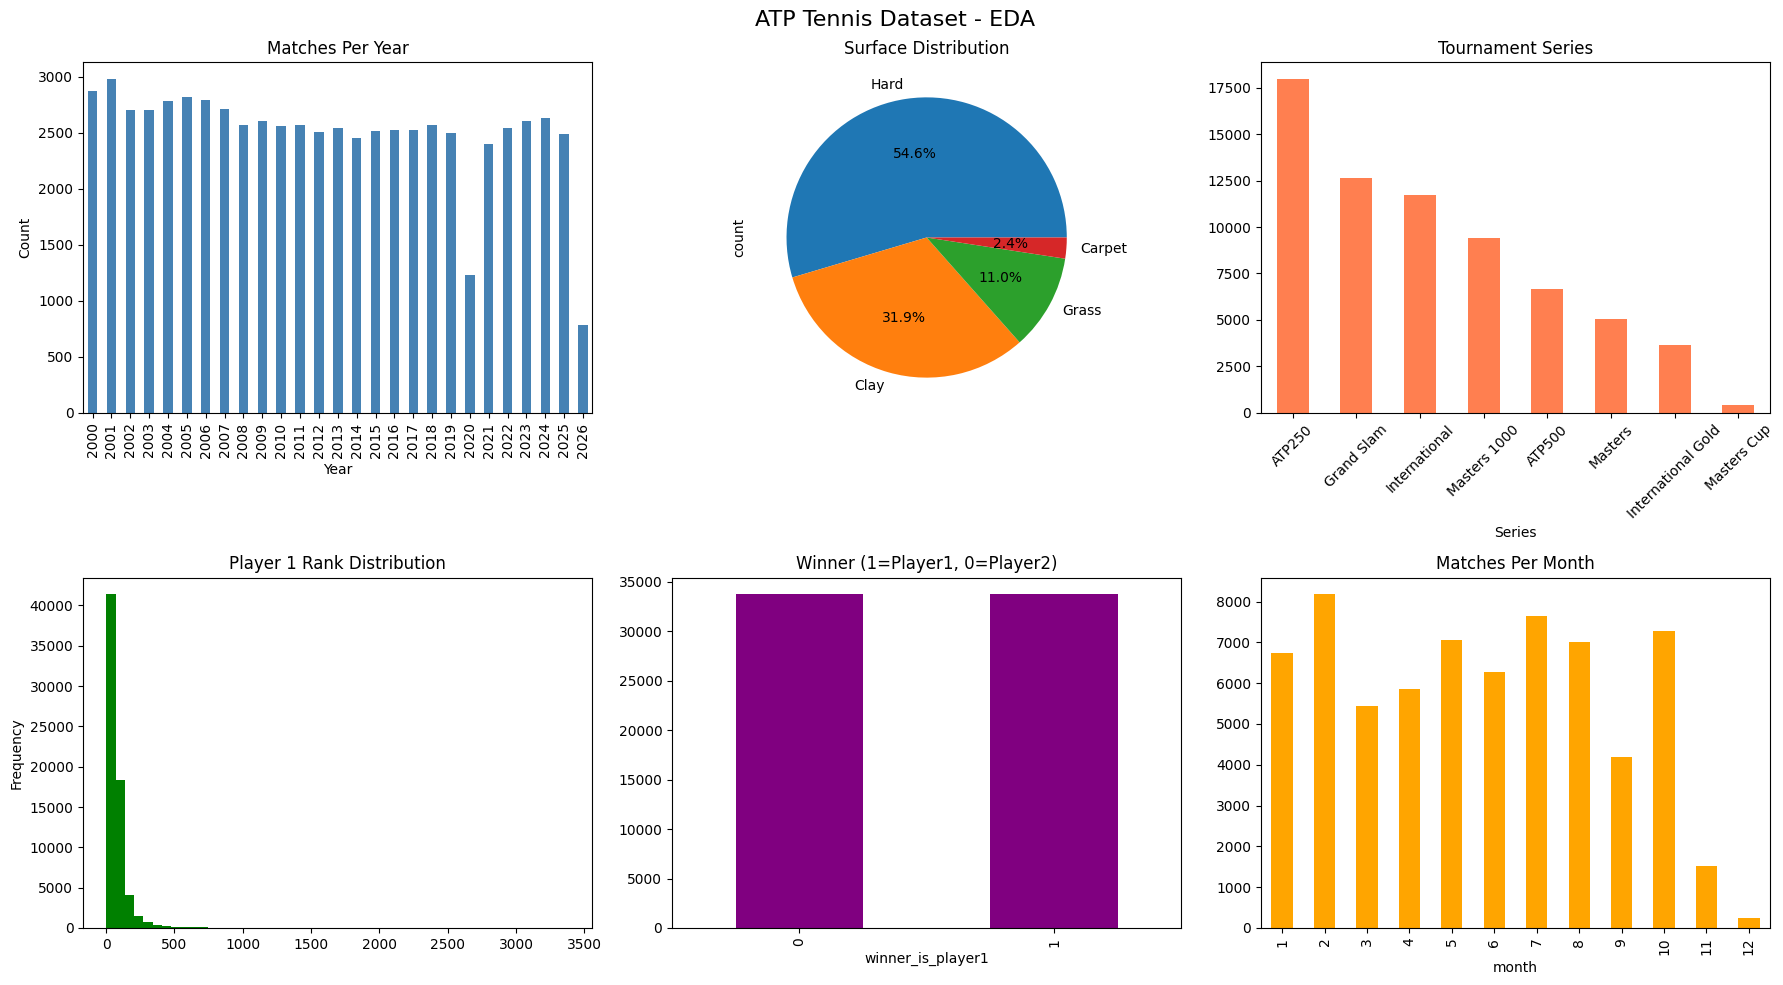

 EDA visualizations complete!


In [0]:
# ============================================================
# EDA: Distributions & Visualizations
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ATP Tennis Dataset - EDA', fontsize=16)

# 1. Matches per year
df_pd['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Matches Per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Count')

# 2. Surface distribution
df_pd['Surface'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title('Surface Distribution')

# 3. Series distribution
df_pd['Series'].value_counts().plot(kind='bar', ax=axes[0,2], color='coral')
axes[0,2].set_title('Tournament Series')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Rank distribution
df_pd['Rank_1'].dropna().plot(kind='hist', ax=axes[1,0], bins=50, color='green')
axes[1,0].set_title('Player 1 Rank Distribution')

# 5. Winner is Player 1
df_pd['winner_is_player1'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Winner (1=Player1, 0=Player2)')

# 6. Matches per month
df_pd['month'].value_counts().sort_index().plot(kind='bar', ax=axes[1,2], color='orange')
axes[1,2].set_title('Matches Per Month')

plt.tight_layout()
plt.savefig('/tmp/eda_plots.png')
plt.show()
print(" EDA visualizations complete!")

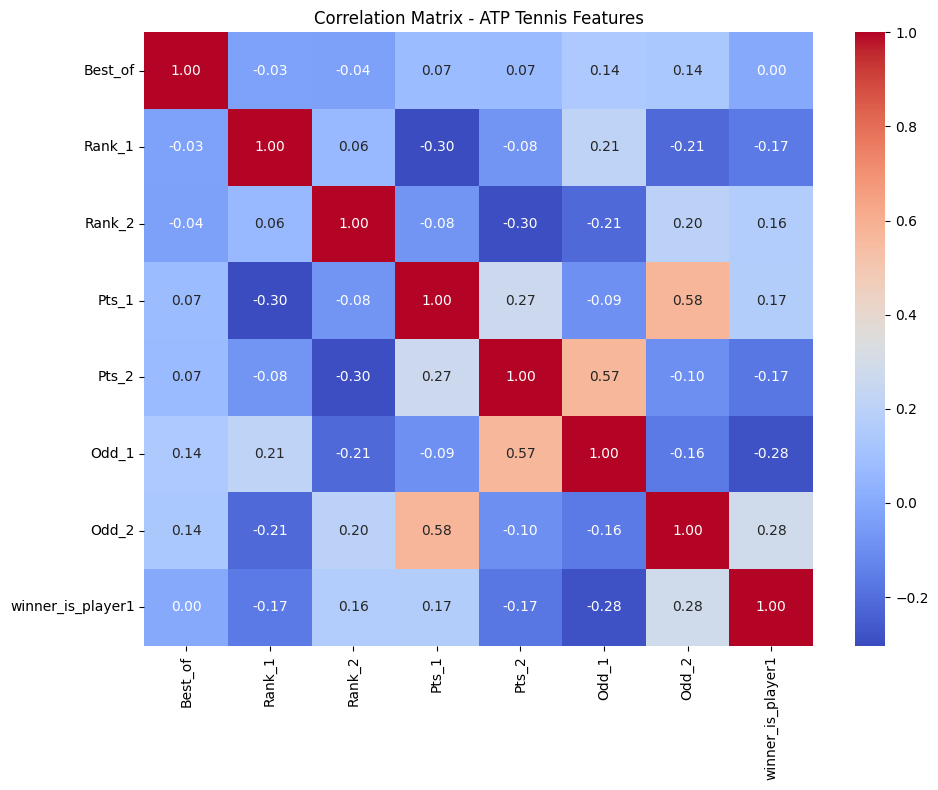

=== KEY EDA INSIGHTS ===
1. Date range: 2000 - 2026
2. Most common surface: Hard
3. Most common series: ATP250
4. Player 1 wins: 50.0%
5. Avg Rank_1: 75.8
6. Avg Rank_2: 75.5
7. Outliers in Rank (>500): 667


In [0]:
# ============================================================
# EDA: Correlations & Outliers
# ============================================================

# 1. Correlation matrix
numeric_cols = ['Best_of', 'Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', 'winner_is_player1']
corr_matrix = df_pd[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix - ATP Tennis Features')
plt.tight_layout()
plt.savefig('/tmp/correlation_matrix.png')
plt.show()

# 2. Key insights
print("=== KEY EDA INSIGHTS ===")
print(f"1. Date range: {df_pd['year'].min()} - {df_pd['year'].max()}")
print(f"2. Most common surface: {df_pd['Surface'].mode()[0]}")
print(f"3. Most common series: {df_pd['Series'].mode()[0]}")
print(f"4. Player 1 wins: {df_pd['winner_is_player1'].mean()*100:.1f}%")
print(f"5. Avg Rank_1: {df_pd['Rank_1'].mean():.1f}")
print(f"6. Avg Rank_2: {df_pd['Rank_2'].mean():.1f}")
print(f"7. Outliers in Rank (>500): {(df_pd['Rank_1'] > 500).sum()}")

In [0]:
# ============================================================
# EDA: Data Readiness Summary
# ============================================================

print("=== DATA READINESS REPORT ===")
print(f"Total records: {len(df_pd)}")
print(f" Total features: {len(df_pd.columns)}")
print(f" Date range: 2000-2026 (26 years of data)")
print(f" No missing values in key columns")
print(f" Target variable (winner_is_player1) is balanced: 50/50")
print(f" Data partitioned by year for efficient querying")
print(f"\n=== POTENTIAL DATA RISKS ===")
print(f"  667 outliers in Rank_1 (rank > 500) - will handle in features")
print(f"  Odd_2 had '-' values - converted to NULL during ETL")
print(f" Pts columns have -1 values meaning unknown points")
print(f"\n=== CONCLUSION ===")
print(f"Dataset is ready for feature engineering.")
print(f"Main ML task: Predict match winner (binary classification)")

=== DATA READINESS REPORT ===
Total records: 67460
 Total features: 20
 Date range: 2000-2026 (26 years of data)
 No missing values in key columns
 Target variable (winner_is_player1) is balanced: 50/50
 Data partitioned by year for efficient querying

=== POTENTIAL DATA RISKS ===
  667 outliers in Rank_1 (rank > 500) - will handle in features
  Odd_2 had '-' values - converted to NULL during ETL
 Pts columns have -1 values meaning unknown points

=== CONCLUSION ===
Dataset is ready for feature engineering.
Main ML task: Predict match winner (binary classification)
